### Environment Setup

Install required libraries for sentence embeddings, clustering, and visualization.

In [1]:
!pip install -q sentence-transformers hdbscan umap-learn scikit-learn matplotlib seaborn

### Imports

Import libraries for embedding generation, clustering, evaluation metrics, and visualization.

In [2]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, silhouette_score, adjusted_rand_score

import hdbscan
import umap

import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

Load polarization dataset and preprocess text, labels, and ideology mappings.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

train = pd.read_csv('/content/drive/MyDrive/TwitBot/Polarization_dataset/train.csv')
test  = pd.read_csv('/content/drive/MyDrive/TwitBot/Polarization_dataset/test.csv')
val   = pd.read_csv('/content/drive/MyDrive/TwitBot/Polarization_dataset/val.csv')

df = pd.concat([train, test, val], ignore_index=True)
df = df[['text','label','ideology']].dropna()

df['ideology_num'] = df['ideology'].map({'Left':0, 'Right':1})

print("Dataset size:", df.shape)
df.head()

Mounted at /content/drive
Dataset size: (6000, 4)


,text,label,ideology,ideology_num
0,"years ago, the ADA was signed into law. This w...",0,Left,0
1,Pembroke will soon be home to NH's largest roo...,0,Left,0
2,Yesterday a federal district court judge ruled...,1,Right,1
3,This week is the start of transformational cha...,0,Left,0
4,Journalism isn't a crime. Cybersecurity resear...,0,Left,0


### Embedding Generation

Convert text into dense semantic embeddings using a pre-trained transformer.

In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    df['text'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

embeddings = np.array(embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

### Clustering (HDBSCAN + KMeans)

Perform unsupervised clustering using density-based (HDBSCAN) and centroid-based (KMeans) methods.

In [6]:
hdb = hdbscan.HDBSCAN(min_cluster_size=10)
h_labels = hdb.fit_predict(embeddings)

kmeans = KMeans(n_clusters=5, random_state=42)
k_labels = kmeans.fit_predict(embeddings)

print("HDBSCAN clusters:", len(set(h_labels)))
print("KMeans clusters:", len(set(k_labels)))

HDBSCAN clusters: 3
KMeans clusters: 5


### Dimensionality Reduction (UMAP)

Reduce high-dimensional embeddings into 2D space for visualization.

In [7]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
reduced = reducer.fit_transform(embeddings)

### Visualization: Clusters vs Ground Truth

Compare discovered clusters with true ideological labels in 2D space.

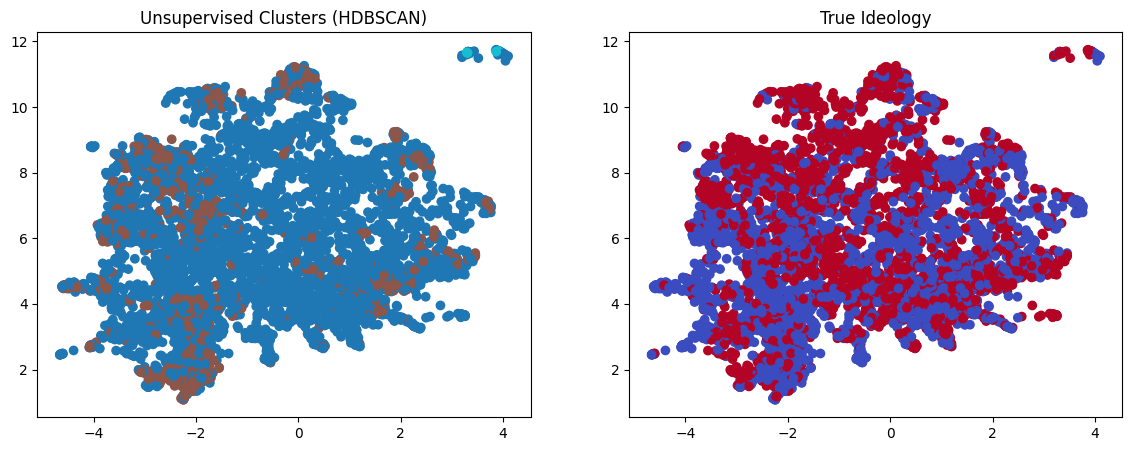

In [8]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].scatter(reduced[:,0], reduced[:,1], c=h_labels, cmap='tab10')
axes[0].set_title("Unsupervised Clusters (HDBSCAN)")

axes[1].scatter(reduced[:,0], reduced[:,1], c=df['ideology_num'], cmap='coolwarm')
axes[1].set_title("True Ideology")

plt.show()

### Polarization Metrics

Compute polarization using inter-cluster and intra-cluster distances.

In [9]:
def polarization_metrics(embeddings, labels):
    valid = labels != -1
    embeddings = embeddings[valid]
    labels = labels[valid]

    unique = np.unique(labels)
    if len(unique) < 2:
        return 0,0,0

    centers = []
    intra_list = []

    for l in unique:
        pts = embeddings[labels == l]
        center = pts.mean(axis=0)

        centers.append(center)
        intra_list.append(np.mean(pairwise_distances(pts, [center])))

    centers = np.vstack(centers)

    inter = np.mean(pairwise_distances(centers))
    intra = np.mean(intra_list)

    normalized = inter / (inter + intra + 1e-6)

    return normalized, inter, intra


score, inter, intra = polarization_metrics(embeddings, h_labels)

print("Polarization Index:", round(score,4))
print("Inter-cluster distance:", round(inter,4))
print("Intra-cluster distance:", round(intra,4))

Polarization Index: 0.3361
Inter-cluster distance: 0.3826
Intra-cluster distance: 0.756


### Clustering Quality Metrics

Evaluate clustering quality using Silhouette Score and ideological alignment (ARI).

In [10]:
print("KMeans Silhouette:", silhouette_score(embeddings, k_labels))

if len(set(h_labels)) > 1:
    print("HDBSCAN Silhouette:",
          silhouette_score(embeddings[h_labels!=-1],
                           h_labels[h_labels!=-1]))

mask = h_labels != -1
ari = adjusted_rand_score(df['ideology_num'][mask], h_labels[mask])

print("Ideology Alignment (ARI):", round(ari,4))

KMeans Silhouette: 0.0329154
HDBSCAN Silhouette: 0.06784167
Ideology Alignment (ARI): 0.0037


### Cluster Purity

Measure how homogeneous clusters are with respect to ideology.

In [11]:
purity_scores = []

for l in set(h_labels):
    if l == -1:
        continue

    subset = df[h_labels == l]
    counts = subset['ideology'].value_counts(normalize=True)

    purity_scores.append(counts.max())

print("Average Cluster Purity:", round(np.mean(purity_scores),4))

Average Cluster Purity: 0.7155


### Inter-Cluster Distance Heatmap

Visualize distances between cluster centers.

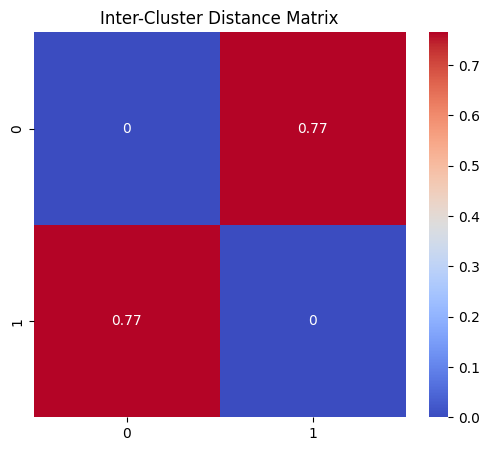

In [12]:
centers = []

for l in set(h_labels):
    if l == -1:
        continue
    centers.append(embeddings[h_labels == l].mean(axis=0))

centers = np.vstack(centers)
dist_matrix = pairwise_distances(centers)

plt.figure(figsize=(6,5))
sns.heatmap(dist_matrix, annot=True, cmap="coolwarm")
plt.title("Inter-Cluster Distance Matrix")
plt.show()

### Echo Chamber Strength

Quantify separation strength between clusters.

In [13]:
echo_strength = inter / (intra + 1e-6)
print("Echo Chamber Strength:", round(echo_strength,4))

Echo Chamber Strength: 0.5062


### Density Visualization

Visualize density of discourse in embedding space.

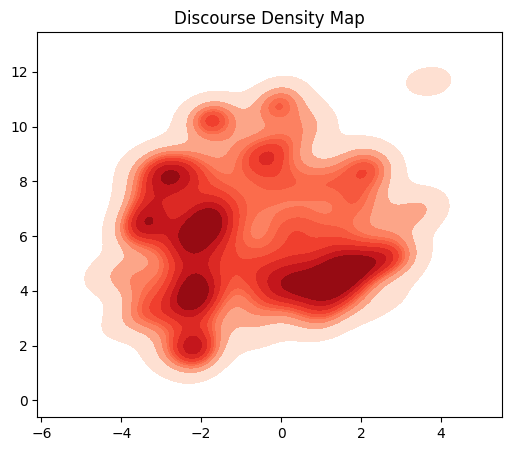

In [14]:
plt.figure(figsize=(6,5))
sns.kdeplot(
    x=reduced[:,0],
    y=reduced[:,1],
    fill=True,
    cmap="Reds",
    thresh=0.05
)
plt.title("Discourse Density Map")
plt.show()

### Cluster Interpretation

Inspect representative text samples from each cluster.

In [15]:
for l in set(h_labels):
    if l == -1:
        continue

    print(f"\nCluster {l} Sample Texts:")
    sample = df[h_labels == l]['text'].head(3)

    for s in sample:
        print("-", s[:120])


Cluster 0 Sample Texts:
- If you're looking for affordable health care, join the more than Americans who recently signed up for a plan under the A
- Now that this is over, I look forward to the Biden administration working in concert with California to set new standard
- Congress needs to pass two important infrastructure bills, but ONLY ONE is a climate bill. Say it with me: No Climate, N

Cluster 1 Sample Texts:
- El rgimen secuestr al activista cubano Loreto Hernndez Garca y su esposa Donaida Prez, familiares del ex-preso poltico c
- From a family friend: Things are much more serious than what is being reported in Cuba. Theres no food. Yesterday, just 
- Fue un placer hablar con . Es horrible escuchar las atrocidades que est cometiendo el rgimen cubano contra el valiente l


### Intervention Experiments

Evaluate impact of node removal on polarization using random and structured strategies.

In [16]:
baseline_score, inter, intra = polarization_metrics(embeddings, h_labels)

# Random removal
def simulate_random_removal(embeddings, remove_ratio=0.2):
    n = len(embeddings)
    keep = int(n*(1-remove_ratio))
    idx = np.random.choice(n, keep, replace=False)
    return embeddings[idx]

scores_random = []
for _ in range(5):
    emb = simulate_random_removal(embeddings, 0.2)
    lbl = hdbscan.HDBSCAN(min_cluster_size=10).fit_predict(emb)
    s,_,_ = polarization_metrics(emb, lbl)
    scores_random.append(s)

# Structured removal
def remove_largest_cluster(embeddings, labels):
    valid = labels != -1
    embeddings = embeddings[valid]
    labels = labels[valid]

    unique, counts = np.unique(labels, return_counts=True)
    largest = unique[np.argmax(counts)]

    return embeddings[labels != largest]

emb_structured = remove_largest_cluster(embeddings, h_labels)
lbl_structured = hdbscan.HDBSCAN(min_cluster_size=10).fit_predict(emb_structured)

structured_score,_,_ = polarization_metrics(emb_structured, lbl_structured)

print("Baseline:", baseline_score)
print("Random Removal:", np.mean(scores_random))
print("Structured Removal:", structured_score)

Baseline: 0.33605757
Random Removal: 0.46598172
Structured Removal: 0


### FINAL COMPARISON VISUALIZATION

Compare polarization under different intervention strategies.

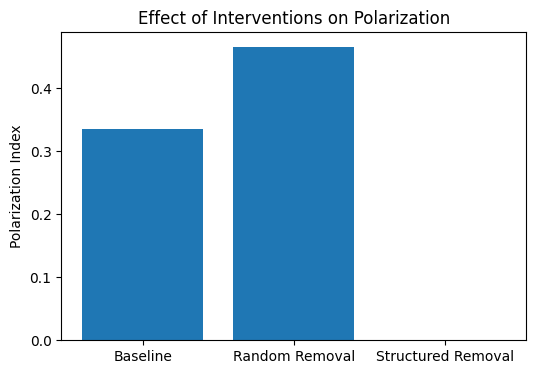

In [17]:
labels_exp = ["Baseline", "Random Removal", "Structured Removal"]
values = [
    baseline_score,
    np.mean(scores_random),
    structured_score
]

plt.figure(figsize=(6,4))
plt.bar(labels_exp, values)
plt.title("Effect of Interventions on Polarization")
plt.ylabel("Polarization Index")
plt.show()

## Gradio Dashboard

In [ ]:
!pip install gradio

In [21]:
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 🔹 1. CLUSTER VISUALIZATION
# -------------------------------
def plot_clusters(method):
    plt.figure()

    if method == "HDBSCAN":
        labels = h_labels
        title = "HDBSCAN Clusters"
    else:
        labels = k_labels
        title = "KMeans Clusters"

    plt.scatter(reduced[:,0], reduced[:,1], c=labels)
    plt.title(title)

    return plt.gcf()

# -------------------------------
# 🔹 2. POLARIZATION METRICS
# -------------------------------
def show_metrics():
    return {
        "Baseline Polarization": round(baseline_score,4),
        "Random Removal (avg)": round(np.mean(scores_random),4),
        "Structured Removal": round(structured_score,4),
        "Echo Strength": round(inter/(intra+1e-6),4)
    }

# -------------------------------
# 🔹 3. SAMPLE TEXTS FROM CLUSTER
# -------------------------------
def get_cluster_samples(cluster_id):
    cluster_id = int(cluster_id)

    if cluster_id not in set(h_labels):
        return "Invalid cluster ID"

    sample = df[h_labels == cluster_id]['text'].head(5)

    return "\n\n".join(sample.tolist())

# -------------------------------
# 🔹 4. INTERVENTION SIMULATION
# -------------------------------
def simulate_intervention(method):
    if method == "Random Removal":
        return f"Avg Polarization: {np.mean(scores_random):.4f}"
    else:
        return f"Polarization after removing largest cluster: {structured_score:.4f}"

# -------------------------------
# 🔹 5. HEATMAP
# -------------------------------
def plot_heatmap():
    centers = []

    for l in set(h_labels):
        if l == -1:
            continue
        centers.append(embeddings[h_labels == l].mean(axis=0))

    centers = np.vstack(centers)

    from sklearn.metrics import pairwise_distances
    dist_matrix = pairwise_distances(centers)

    plt.figure()
    import seaborn as sns
    sns.heatmap(dist_matrix, cmap="coolwarm")
    plt.title("Cluster Distance Heatmap")

    return plt.gcf()

# -------------------------------
# 🔹 DASHBOARD UI
# -------------------------------
with gr.Blocks() as demo:

    gr.Markdown("# 🧠 Polarization Analysis Dashboard")

    # 🔹 TAB 1 — Cluster Visualization
    with gr.Tab("📊 Clusters"):
        method_dropdown = gr.Dropdown(
            ["HDBSCAN", "KMeans"],
            label="Clustering Method"
        )

        plot_btn = gr.Button("Show Clusters")
        plot_output = gr.Plot()

        plot_btn.click(
            fn=plot_clusters,
            inputs=method_dropdown,
            outputs=plot_output
        )

    # 🔹 TAB 2 — Metrics
    with gr.Tab("📈 Metrics"):
        metrics_btn = gr.Button("Show Metrics")
        metrics_output = gr.JSON()

        metrics_btn.click(
            fn=show_metrics,
            outputs=metrics_output
        )

    # 🔹 TAB 3 — Cluster Inspection
    with gr.Tab("🔍 Cluster Explorer"):
        cluster_input = gr.Number(label="Enter Cluster ID")
        sample_btn = gr.Button("Get Sample Texts")

        sample_output = gr.Textbox(lines=10)

        sample_btn.click(
            fn=get_cluster_samples,
            inputs=cluster_input,
            outputs=sample_output
        )

    # 🔹 TAB 4 — Intervention
    with gr.Tab("⚙️ Intervention Analysis"):
        method_radio = gr.Radio(
            ["Random Removal", "Structured Removal"],
            label="Intervention Type"
        )

        sim_btn = gr.Button("Run Simulation")
        sim_output = gr.Textbox()

        sim_btn.click(
            fn=simulate_intervention,
            inputs=method_radio,
            outputs=sim_output
        )

    # 🔹 TAB 5 — Heatmap
    with gr.Tab("🔥 Cluster Distance"):
        heatmap_btn = gr.Button("Show Heatmap")
        heatmap_plot = gr.Plot()

        heatmap_btn.click(
            fn=plot_heatmap,
            outputs=heatmap_plot
        )
demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2f10e5c8956b7ad5ff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2f10e5c8956b7ad5ff.gradio.live
